In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import lightgbm as lgbm
from lightgbm import Booster
#import structureboost as stb
import ml_insights as mli
from sklearn.metrics import log_loss
pd.set_option('display.max_columns',1000)
pd.set_option('display.max_rows',1000)

from aggregateDataFunctions import groupsOf3Aggregate, groupOf9Aggregate

mainDf = pd.read_csv('CombinedWithWinDashesNaN.csv')
oddsDf = pd.read_csv('DashesChangedOddsDataTest.csv')
aggregateData = groupsOf3Aggregate

modelName = 'CombineLineupsInGroupsOf3_0.6322267482031646.txt'
modelFile = os.path.join("models", modelName)
model1 = lgbm.Booster(model_file=modelFile)


In [2]:
mainDf = aggregateData(mainDf)

trainX = mainDf.iloc[:13000,:]
validX = mainDf.iloc[13000:14500,:]
testX = mainDf.iloc[14500:,:]

trainY = trainX['home_win'].to_numpy()
validY = validX['home_win'].to_numpy()
testY = testX['home_win'].to_numpy()

trainX = trainX.drop("home_win", axis='columns')
validX = validX.drop("home_win", axis='columns')
testX = testX.drop("home_win", axis='columns')

testX2024 = pd.read_csv('2024testWithOdds.csv')

c:\Users\nhleo\Downloads\MLB-Moneyline\aggregateDataFunctions.py:72: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  new_df[mean_col_name] = group_mean
c:\Users\nhleo\Downloads\MLB-Moneyline\aggregateDataFunctions.py:73: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  new_df[std_col_name] = group_std
c:\Users\nhleo\Downloads\MLB-Moneyline\aggregateDataFunctions.py:72: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all

In [3]:
hv_mean = mainDf['home_win'].sum() / 16074
testX = testX.astype(float)

preds_lgbm = model1.predict(testX)
ll_test = log_loss(testY, preds_lgbm)
preds_lgbm_test = model1.predict(testX)
sv_lgbm = model1.predict(testX, pred_contrib=True)
sv_lgbm = pd.DataFrame(sv_lgbm)
sv_lgbm.columns = list(testX.columns)+['Intercept']
sv_vec = sv_lgbm.abs().mean().sort_values(ascending=False)
print('\nAvg Shap Vals')
print(sv_vec)   

oddsDf['win_odds'] = np.where(
    oddsDf['home_win'] == 1,
    oddsDf['homeDec'],
    oddsDf['awayDec']
)
preds_weighted = 1 * preds_lgbm + 0 * oddsDf['combinedOdds']
log_loss(testY, preds_weighted), log_loss(testY, oddsDf.win_odds), log_loss(testY, hv_mean*np.ones(len(testY)))


Avg Shap Vals
woba_pitch_away                                0.212109
woba_pitch_home                                0.191078
Intercept                                      0.154167
woba_bullpen_away                              0.078383
slg_pitch_away                                 0.069546
woba_group1_away                               0.050691
iso_group3_away                                0.042056
woba_bullpen_home                              0.040789
woba_group2_home                               0.040331
obp_pitch_home                                 0.039270
slg_pitch_home                                 0.037605
ba_group1_home                                 0.037526
iso_pitch_home                                 0.036926
ba_pitch_away                                  0.031025
xwoba_group2_home                              0.029621
slg_bullpen_away                               0.028037
hits_bullpen_home                              0.026993
iso_bullpen_away                 

(0.6322267482031646, 0.6528598482231269, 0.6925878945236387)

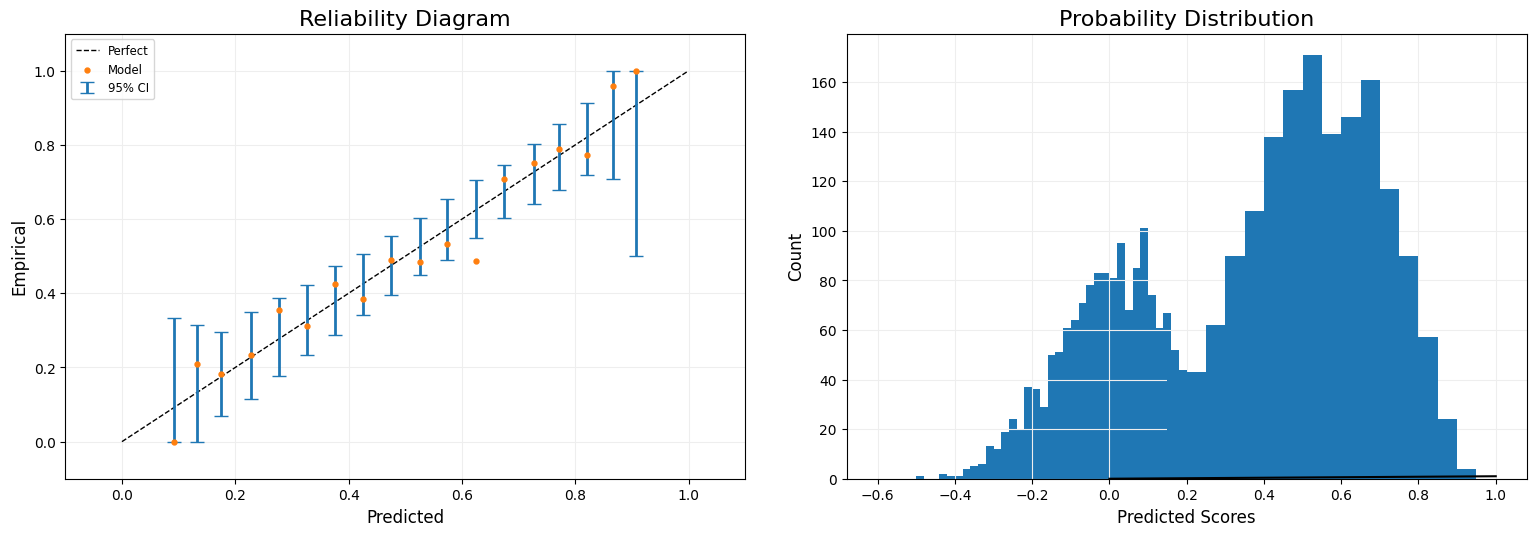

In [4]:
rd = mli.get_range_dict(trainX)
plot_pts = testX.sample(3, random_state=42)
#mli.ice_plot(model1, plot_pts, 'woba_pitch_away', mli.get_range_dict(trainX), plots_per_row=2)
#print(testX.columns[832])
plt.figure(figsize=(16,6))
mli.plot_reliability_diagram(testY, preds_lgbm, show_histogram=True)
plt.scatter(oddsDf.combinedOdds, preds_lgbm, marker='.', alpha=.1)
plt.plot([0,1],[0,1], color='k')
test_disc = preds_lgbm - oddsDf.combinedOdds
# Assign so array isn printed
t = plt.hist(test_disc, bins=np.linspace(-.6,.6,61))

# Can fix the thing bein outside the confidence interval by adding a logistic 

In [27]:
textX2024 = aggregateData(testX2024)

curTestOddsDf = textX2024[['home_win', 'homeDec', 'awayDec', 'combinedOdds']].copy()
curTestOddsDf['win_odds'] = np.where(
    curTestOddsDf['home_win'] == 1,
    curTestOddsDf['homeDec'],
    curTestOddsDf['awayDec']
)
textX2024 = textX2024.drop(labels = ['homeDec', 'awayDec', 'combinedOdds'], axis = 'columns')
curTestY = textX2024['home_win'].to_numpy()
textX2024 = textX2024.drop("home_win", axis='columns')

curTest_preds = model1.predict(textX2024)

log_loss(curTestY, curTest_preds), log_loss(curTestY, curTestOddsDf.win_odds), log_loss(curTestY, hv_mean*np.ones(len(curTestY)))

c:\Users\nhleo\Downloads\MLB-Moneyline\aggregateDataFunctions.py:72: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  new_df[mean_col_name] = group_mean
c:\Users\nhleo\Downloads\MLB-Moneyline\aggregateDataFunctions.py:73: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  new_df[std_col_name] = group_std
c:\Users\nhleo\Downloads\MLB-Moneyline\aggregateDataFunctions.py:72: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all

(0.6324670699074184, 0.6486680191296863, 0.6875827389542538)

In [6]:
def binary_log_loss(y_true, y_pred, eps=1e-15):
    """
    Compute binary log loss for each instance.
    
    Parameters:
        y_true (np.array): Array of binary outcomes (0 or 1).
        y_pred (np.array): Array of predicted probabilities for the positive class.
        eps (float): Small value to avoid log(0).
    
    Returns:
        np.array: Log loss for each instance.
    """
    # Clip predictions to avoid numerical issues
    y_pred = np.clip(y_pred, eps, 1 - eps)
    return -(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

def compute_fractional_kelly_multiplier(y_true, model_preds, market_preds):
    """
    Calculate the fractional Kelly multiplier based on the difference between
    market odds (after vig) and your model's predictions.
    
    Parameters:
        y_true (np.array): Array of binary outcomes (0 or 1) for each game.
        model_preds (np.array): Array of your model's predicted probabilities for the positive class.
        market_preds (np.array): Array of market (book) probabilities for the positive class.
    
    Returns:
        alpha (float): The fractional Kelly multiplier.
        mean_edge (float): The average per-game edge.
        variance_edge (float): The variance of the per-game edge.
    """
    # Compute per-sample log losses
    model_losses = binary_log_loss(y_true, model_preds)
    market_losses = binary_log_loss(y_true, market_preds)
    
    # Compute per-game edge: market loss minus model loss
    edges = market_losses - model_losses
    
    # Calculate the average edge and sample variance of the edge
    mean_edge = np.mean(edges)
    variance_edge = np.var(edges, ddof=1)
    
    # If our model does not have a positive edge, we shouldn't bet
    if mean_edge <= 0:
        return 0.0, mean_edge, variance_edge
    
    # Compute the fractional Kelly multiplier
    alpha = (mean_edge ** 2) / (mean_edge ** 2 + variance_edge)
    
    return alpha, mean_edge, variance_edge

# Example usage:
# Assuming you already have your test outcomes, model predictions, and market odds in variables:
#
# curTestY         --> your binary outcomes (home_win) as a numpy array
# curTest_preds    --> your model's predicted probabilities for home winning
# curTestOddsDf.win_odds  --> the market odds as a numpy array (for the winning team)
#
# You can then calculate:
#
alpha, mean_edge, variance_edge = compute_fractional_kelly_multiplier(curTestY, curTest_preds, curTestOddsDf.win_odds)
#
print("Fractional Kelly multiplier: ", alpha)
print("Average edge: ", mean_edge)
print("Edge variance: ", variance_edge)




Fractional Kelly multiplier:  0.0020283049841947932
Average edge:  0.016200949222267905
Edge variance:  0.12914151816497746


C:\Users\nhleo\AppData\Local\Temp\ipykernel_22592\634844824.py:51: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  betDf = pd.concat([betDf, curGameBet], axis=0)


Total zero bets: 0
Net result: 141.11332410761992
Expected result: 141.64638204023404
Total bets: 368


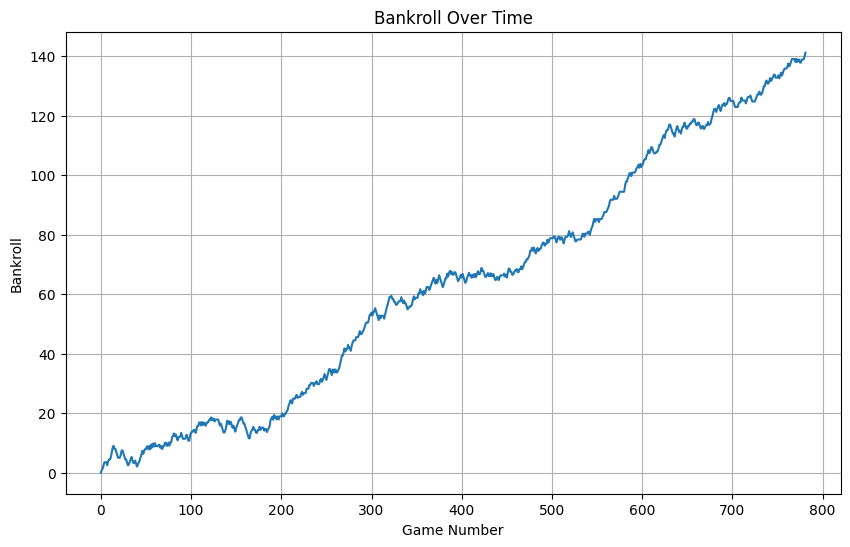

In [7]:
def buildBetCsv(predsnp, testXDf, testYnp, oddsDf):
    predsDf = pd.DataFrame(data = predsnp, columns = ["home_win_preds"])
    testYDf = pd.DataFrame(data = testYnp, columns = ["home_win"])
    testXDf = testXDf.reset_index()

    justOddsDf = oddsDf.filter(['homeDec', 'awayDec', 'combinedOdds'])

    betAnalysis = pd.concat([testXDf, testYDf, justOddsDf, predsDf], axis = 1)
    betAnalysis = betAnalysis.drop("index", axis='columns')

    #print(betAnalysis)
    bankroll = 0
    zeroCount = 0
    betDf = pd.DataFrame(data = [], columns = ["home_bet", "away_bet", "home_net", "away_net", "net_bets","expected_value", "bankroll"])
    
    for ind in betAnalysis.index:
        homeWin = float(betAnalysis['home_win'][ind])
        predOddsHome = float(betAnalysis['home_win_preds'][ind])
        predOddsAway = 1 - predOddsHome
        homeLine = float(betAnalysis['homeDec'][ind])
        awayLine = float(betAnalysis['awayDec'][ind])
        homeBet = 0
        awayBet = 0

        if predOddsHome - homeLine > 0.03:
            homeBet = 1
            if homeBet < 0.0049:
                zeroCount += 1
        if predOddsAway - awayLine > 0.03:
            awayBet = 1
            if awayBet < 0.0049:
                zeroCount += 1

        if homeWin == 1:
            homeNet = (homeBet / homeLine) - homeBet
            awayNet = (-1 * awayBet)
        if homeWin == 0:
            awayNet = (awayBet / awayLine) - awayBet
            homeNet = (-1 * homeBet)

        gameNet = homeNet + awayNet
        bankroll += gameNet
        ev = 0
        if homeBet > 0:
            ev = (predOddsHome * ((homeBet / homeLine) - homeBet)) - (predOddsAway * homeBet)
        elif awayBet > 0:
            ev = (predOddsAway * ((awayBet / awayLine) - awayBet)) - (predOddsHome * awayBet)

        betData = [homeBet, awayBet, homeNet, awayNet, gameNet, ev, bankroll]
        curGameBet = pd.DataFrame([betData], columns = ["home_bet", "away_bet", "home_net", "away_net", "net_bets", "expected_value", "bankroll"])
        betDf = pd.concat([betDf, curGameBet], axis=0)
    
    print("Total zero bets: " + str(zeroCount))
    return betDf

test = buildBetCsv(curTest_preds, textX2024, curTestY, curTestOddsDf)

print("Net result: " + str(test['net_bets'].sum()))
print("Expected result: " + str(test['expected_value'].sum()))
counts = 0
for bet in test['net_bets']:
    if bet > 0:
        counts+=1

print("Total bets: " + str(counts))

# Create an explicit x-axis representing the game number (0-indexed).
game_numbers = range(len(test))

# Plot the bankroll progression:
plt.figure(figsize=(10, 6))
plt.plot(game_numbers, test['bankroll'], marker='', linestyle='-')
plt.xlabel('Game Number')
plt.ylabel('Bankroll')
plt.title('Bankroll Over Time')
plt.grid(True)
plt.show()

test.to_csv('simulatedBets.csv', index=False)


C:\Users\nhleo\AppData\Local\Temp\ipykernel_22592\549663793.py:72: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  betDf = pd.concat([betDf, curGameBet], axis=0)


Losers: 221
Winners: 394
Total: 615
Net result: 675629.3391548936
Expected result: 553639.4088605406


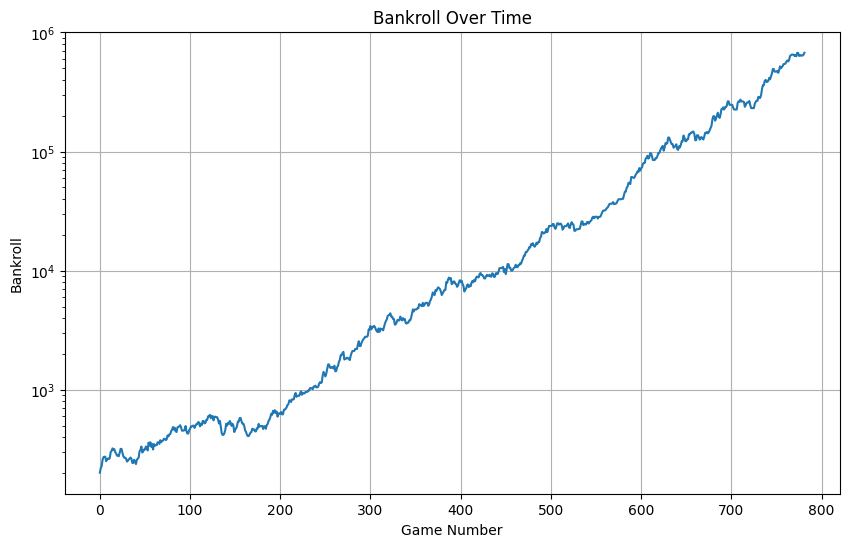

In [23]:
def buildBetCsvKelly(predsnp, testXDf, testYnp, oddsDf, bankroll: int, kellyFrac: float):
    predsDf = pd.DataFrame(data = predsnp, columns = ["home_win_preds"])
    testYDf = pd.DataFrame(data = testYnp, columns = ["home_win"])
    testXDf = testXDf.reset_index()

    justOddsDf = oddsDf.filter(['homeDec', 'awayDec', 'combinedOdds'])

    betAnalysis = pd.concat([testXDf, testYDf, justOddsDf, predsDf], axis = 1)
    betAnalysis = betAnalysis.drop("index", axis='columns')

    #print(betAnalysis)

    betDf = pd.DataFrame(data = [], columns = ["home_bet", "away_bet", "home_net", "away_net", "net_bets", "expected_value", "bankroll"])
    maxPercent = 0
    maxPercentIndex = 0
    winners = 0
    losers = 0
    total = 0
    
    for ind in betAnalysis.index:
        homeWin = float(betAnalysis['home_win'][ind])
        predOddsHome = float(betAnalysis['home_win_preds'][ind])
        predOddsAway = 1 - predOddsHome
        homeLine = float(betAnalysis['homeDec'][ind])
        awayLine = float(betAnalysis['awayDec'][ind])
        homeBet = 0
        awayBet = 0
        

        if predOddsHome - homeLine > 0.02:
            homeBet = (bankroll * kellyFrac)*(predOddsHome - homeLine) / (1 - homeLine)
            if homeBet / bankroll > maxPercent:
                maxPercent = homeBet/bankroll
                maxPercentIndex = ind      
                 

                
        if predOddsAway - awayLine > 0.02:
            awayBet = (bankroll * kellyFrac)*(predOddsAway - awayLine) / (1 - awayLine)
            if awayBet / bankroll > maxPercent:
                maxPercent = awayBet/bankroll
                maxPercentIndex = ind


        if homeWin == 1:
            homeNet = (homeBet / homeLine) - homeBet
            awayNet = (-1 * awayBet)
        if homeWin == 0:
            awayNet = (awayBet / awayLine) - awayBet
            homeNet = (-1 * homeBet)

        gameNet = homeNet + awayNet
        
        ev = 0
        bankroll += gameNet
        
        #print(gameNet)
        if gameNet > 0.0:
            winners += 1
            total += 1
        elif gameNet < 0.0:
            losers += 1
            total += 1

        if homeBet > 0:
            ev = (predOddsHome * ((homeBet / homeLine) - homeBet)) - (predOddsAway * homeBet)
        elif awayBet > 0:
            ev = (predOddsAway * ((awayBet / awayLine) - awayBet)) - (predOddsHome * awayBet)

        betData = [homeBet, awayBet, homeNet, awayNet, gameNet, ev, bankroll]
        curGameBet = pd.DataFrame([betData], columns = ["home_bet", "away_bet", "home_net", "away_net", "net_bets", "expected_value", "bankroll"])
        betDf = pd.concat([betDf, curGameBet], axis=0)
    
    print("Losers: " + str(losers))
    print("Winners: " + str(winners))
    print("Total: " + str(total))
    return betDf

test = buildBetCsvKelly(curTest_preds, textX2024, curTestY, curTestOddsDf, 200, .2)

print("Net result: " + str(test['net_bets'].sum()))
print("Expected result: " + str(test['expected_value'].sum()))

# Create an explicit x-axis representing the game number (0-indexed).
game_numbers = range(len(test))

# Plot the bankroll progression:
plt.figure(figsize=(10, 6))
plt.plot(game_numbers, test['bankroll'], marker='', linestyle='-')
plt.xlabel('Game Number')
plt.ylabel('Bankroll')
plt.yscale("log")
plt.title('Bankroll Over Time')
plt.grid(True)
plt.show()

test.to_csv('simulatedBets.csv', index=False)


C:\Users\nhleo\AppData\Local\Temp\ipykernel_22592\2662898074.py:56: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  betDf = pd.concat([betDf, curGameBet], axis=0)


Bet Max Hit Count: 15
Net result: 241887.6739892038
Expected result: 219890.4368413845
Total bets: 330


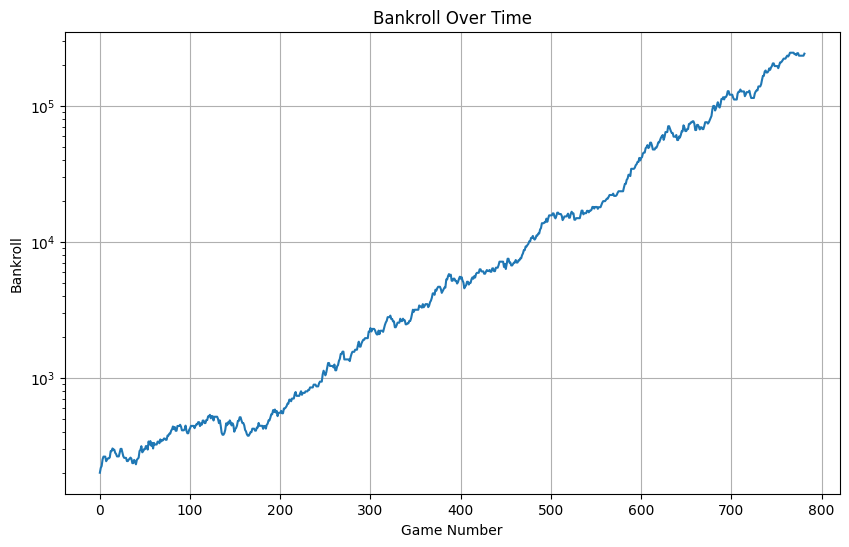

In [9]:
def buildBetCsvKelly(predsnp, testXDf, testYnp, oddsDf, bankroll: int, kellyFrac: float):
    predsDf = pd.DataFrame(data = predsnp, columns = ["home_win_preds"])
    testYDf = pd.DataFrame(data = testYnp, columns = ["home_win"])
    testXDf = testXDf.reset_index()

    justOddsDf = oddsDf.filter(['homeDec', 'awayDec', 'combinedOdds'])

    betAnalysis = pd.concat([testXDf, testYDf, justOddsDf, predsDf], axis = 1)
    betAnalysis = betAnalysis.drop("index", axis='columns')

    #print(betAnalysis)

    betDf = pd.DataFrame(data = [], columns = ["home_bet", "away_bet", "home_net", "away_net", "net_bets", "expected_value", "bankroll"])
    betMaxHit = 0
    
    for ind in betAnalysis.index:
        homeWin = float(betAnalysis['home_win'][ind])
        predOddsHome = float(betAnalysis['home_win_preds'][ind])
        predOddsAway = 1 - predOddsHome
        homeLine = float(betAnalysis['homeDec'][ind])
        awayLine = float(betAnalysis['awayDec'][ind])
        homeBet = 0
        awayBet = 0
        
    
        if predOddsHome - homeLine > 0.05:
            homeBet = (bankroll * kellyFrac)*(predOddsHome - homeLine) / (1 - homeLine)
            if homeBet > 10000:
                homeBet = 10000
                betMaxHit += 1
            
        if predOddsAway - awayLine > 0.05:
            awayBet = (bankroll * kellyFrac)*(predOddsAway - awayLine) / (1 - awayLine)
            if awayBet > 10000:
                awayBet = 10000
                betMaxHit += 1


        if homeWin == 1:
            homeNet = (homeBet / homeLine) - homeBet
            awayNet = (-1 * awayBet)
        if homeWin == 0:
            awayNet = (awayBet / awayLine) - awayBet
            homeNet = (-1 * homeBet)

        gameNet = homeNet + awayNet
        ev = 0
        bankroll += gameNet
        if homeBet > 0:
            ev = (predOddsHome * ((homeBet / homeLine) - homeBet)) - (predOddsAway * homeBet)
        elif awayBet > 0:
            ev = (predOddsAway * ((awayBet / awayLine) - awayBet)) - (predOddsHome * awayBet)

        betData = [homeBet, awayBet, homeNet, awayNet, gameNet, ev, bankroll]
        curGameBet = pd.DataFrame([betData], columns = ["home_bet", "away_bet", "home_net", "away_net", "net_bets", "expected_value", "bankroll"])
        betDf = pd.concat([betDf, curGameBet], axis=0)
    
    print("Bet Max Hit Count: " + str(betMaxHit))
    return betDf

test = buildBetCsvKelly(curTest_preds, textX2024, curTestY, curTestOddsDf, 200, .18)

print("Net result: " + str(test['net_bets'].sum()))
print("Expected result: " + str(test['expected_value'].sum()))
counts = 0
for bet in test['net_bets']:
    if bet > 0:
        counts+=1

print("Total bets: " + str(counts))

# Create an explicit x-axis representing the game number (0-indexed).
game_numbers = range(len(test))

# Plot the bankroll progression:
plt.figure(figsize=(10, 6))
plt.plot(game_numbers, test['bankroll'], marker='', linestyle='-')
plt.xlabel('Game Number')
plt.ylabel('Bankroll')
plt.yscale("log")
plt.title('Bankroll Over Time')
plt.grid(True)
plt.show()

test.to_csv('simulatedBets.csv', index=False)

